## Version 1.0
Gradient-boosted decision tree model for predicting muzzle velocity of standard rifle cartridges using charge weight, bullet weight, burn-rate index, barrel length, and cartridge identity. Cartridges with mixed operational regimes (e.g. .300 AAC Blackout) are intentionally excluded and handled via dedicated sub-models.

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import HistGradientBoostingRegressor

In [38]:
df = pd.read_csv("cleaned_dataset.csv")
df.head()

,cartridge,bullet_diameter,bullet_type,bullet_weight,powder_type,burn_rate_index,charge_weight,velocity_fps,barrel_length,twist_rate,coal,compressed_load
0,223_rem,0.2245,hpfb,36.0,vihtavuori_n130,84,24.1,3786,25.0,12.0,2.181,yes
1,223_rem,0.2245,hpfb,36.0,vihtavuori_n133,89,25.9,3842,25.0,12.0,2.181,yes
2,223_rem,0.2245,hpfb,36.0,vihtavuori_n135,102,26.2,3717,25.0,12.0,2.181,yes
3,223_rem,0.2245,hpfb,36.0,vihtavuori_n140,112,27.0,3514,25.0,12.0,2.181,yes
4,223_rem,0.2245,hpfb,36.0,vihtavuori_n540,117,27.8,3576,25.0,12.0,2.181,yes


In [39]:
numeric_features = ["bullet_weight", "charge_weight", "burn_rate_index", "barrel_length"]
categoric_features = ["cartridge"]
target = "velocity_fps"

X = df[numeric_features + categoric_features]
y = df[target].astype(float)

In [40]:
preprocessor = ColumnTransformer(
    transformers=[
        ("num", "passthrough", numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), categoric_features),
    ],
    remainder="drop"
)

In [41]:
gbrt = HistGradientBoostingRegressor(
    loss="absolute_error",
    random_state=42
)

model = Pipeline([
    ("preprocess", preprocessor),
    ("tree", gbrt)
])

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [43]:
mean_pred = np.full(shape=y_test.shape, fill_value=y_train.mean())
floor_mae = mean_absolute_error(y_test, mean_pred)

model.fit(X_train, y_train)
preds = model.predict(X_test)

model_mae = mean_absolute_error(y_test, preds)
mse = mean_squared_error(y_test, preds)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, preds)

print(f"FLOOR MAE (test): {floor_mae:.2f} fps")
print(f"TREE  MAE (test): {model_mae:.2f} fps")
print(f"TREE RMSE (test): {rmse:.2f} fps")
print(f"TREE   R² (test): {r2:.4f}")

FLOOR MAE (test): 246.56 fps
TREE  MAE (test): 48.08 fps
TREE RMSE (test): 64.71 fps
TREE   R² (test): 0.9564


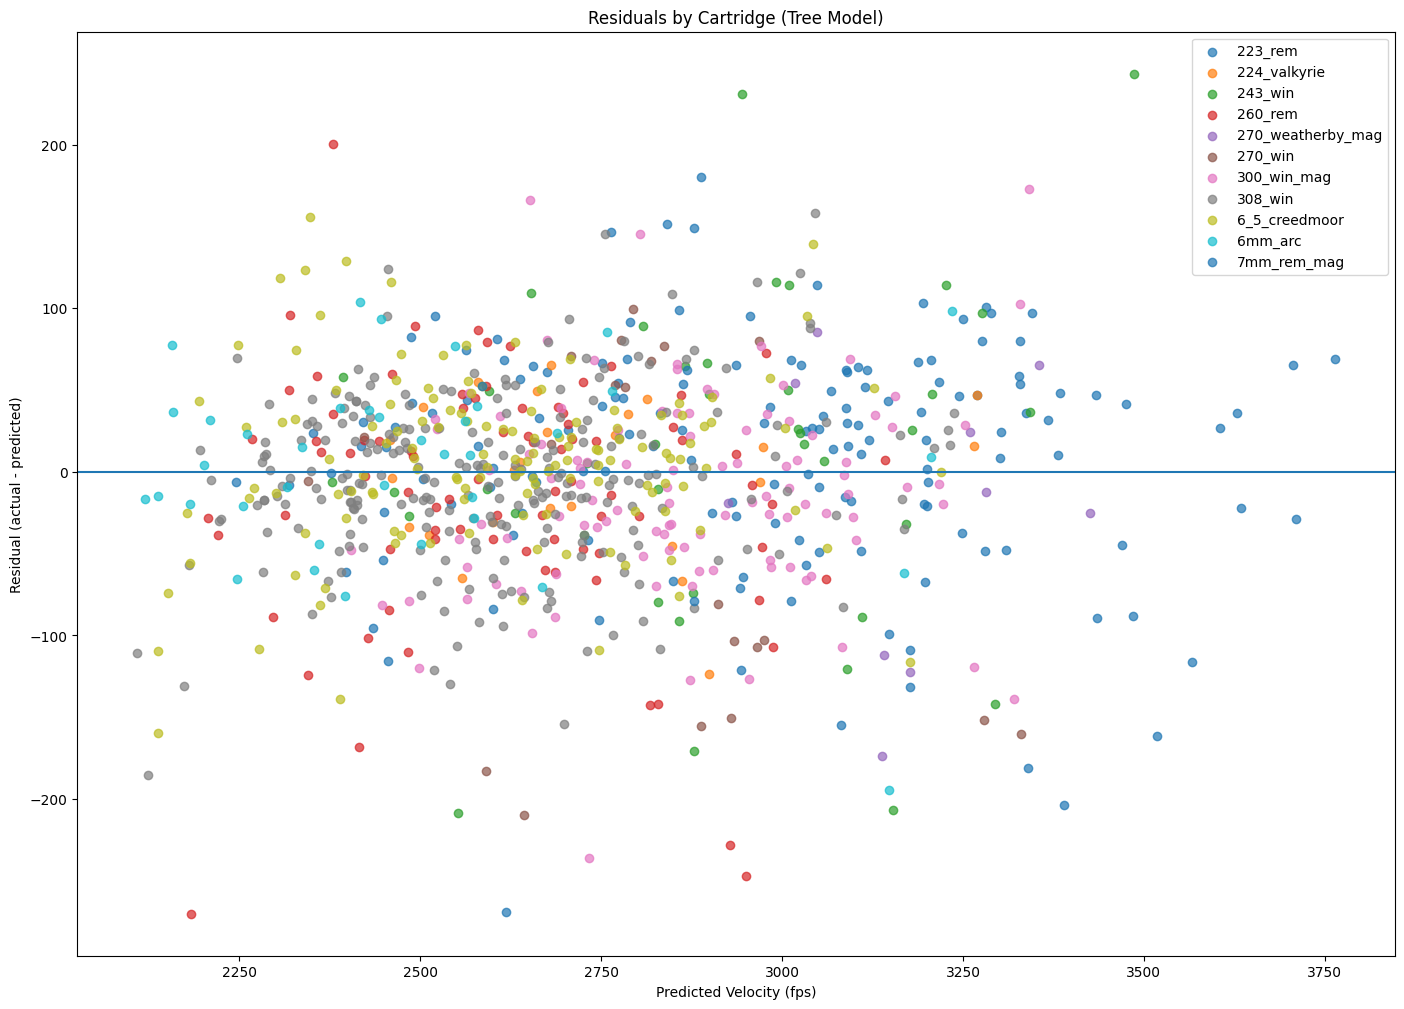

In [44]:
residuals = y_test.to_numpy() - preds
cartridges = X_test["cartridge"].astype(str).to_numpy()

plt.figure(figsize=(17, 12))
for cart in np.unique(cartridges):
    mask = cartridges == cart
    plt.scatter(preds[mask], residuals[mask], label=cart, alpha=0.7)

plt.axhline(0)
plt.xlabel("Predicted Velocity (fps)")
plt.ylabel("Residual (actual - predicted)")
plt.title("Residuals by Cartridge (Tree Model)")
plt.legend()
plt.show()

In [45]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "tree__learning_rate": [0.02, 0.03, 0.05, 0.08, 0.1],
    "tree__max_leaf_nodes": [15, 31, 63, 127, 255],
    "tree__max_depth": [None, 3, 5, 7, 9],
    "tree__min_samples_leaf": [10, 20, 40, 80, 150],
    "tree__l2_regularization": [0.0, 0.1, 0.5, 1.0, 5.0, 10.0],
    "tree__max_bins": [64, 128, 255],
}

search = RandomizedSearchCV(
    estimator=model,
    param_distributions=param_dist,
    n_iter=40,
    scoring="neg_mean_absolute_error",
    cv=5,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best CV MAE:", -search.best_score_)
print("Best params:", search.best_params_)

best_model = search.best_estimator_
best_preds = best_model.predict(X_test)

best_mae = mean_absolute_error(y_test, best_preds)
best_mse = mean_squared_error(y_test, best_preds)
best_rmse = np.sqrt(best_mse)
best_r2 = r2_score(y_test, best_preds)

print(f"BEST TREE  MAE (test): {best_mae:.2f} fps")
print(f"BEST TREE RMSE (test): {best_rmse:.2f} fps")
print(f"BEST TREE   R² (test): {best_r2:.4f}")


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV MAE: 48.252711795483556
Best params: {'tree__min_samples_leaf': 10, 'tree__max_leaf_nodes': 255, 'tree__max_depth': None, 'tree__max_bins': 128, 'tree__learning_rate': 0.1, 'tree__l2_regularization': 1.0}
BEST TREE  MAE (test): 44.48 fps
BEST TREE RMSE (test): 59.87 fps
BEST TREE   R² (test): 0.9626


In [46]:
df_eval = X_test.copy()
df_eval["actual"] = y_test.values
df_eval["pred"] = best_preds
df_eval["abs_error"] = np.abs(df_eval["actual"] - df_eval["pred"])

df_eval.groupby("cartridge")["abs_error"].mean().sort_values()


cartridge
308_win              34.293175
224_valkyrie         36.402477
6_5_creedmoor        39.040744
300_win_mag          40.947488
223_rem              47.887416
6mm_arc              48.900838
260_rem              52.903581
7mm_rem_mag          58.715121
243_win              71.989446
270_weatherby_mag    78.254335
270_win              83.767329
Name: abs_error, dtype: float64